In [1]:
import pandas as pd

titanic = pd.read_csv('../data/titanic.csv')
titanic['age'] = titanic['age'].replace(['?'], [None]).astype('float')
titanic['fare'] = titanic['fare'].replace(['?'], [None]).astype('float')

In [2]:
titanic.info() #what cannot be turned to numeric/float by default == object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      1309 non-null   object 
 10  embarked   1309 non-null   object 
 11  boat       1309 non-null   object 
 12  body       1309 non-null   object 
 13  home.dest  1309 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 143.3+ KB


In [7]:
titanic['name'].astype('string')

0                         Allen, Miss. Elisabeth Walton
1                        Allison, Master. Hudson Trevor
2                          Allison, Miss. Helen Loraine
3                  Allison, Mr. Hudson Joshua Creighton
4       Allison, Mrs. Hudson J C (Bessie Waldo Daniels)
                             ...                       
1304                               Zabour, Miss. Hileni
1305                              Zabour, Miss. Thamine
1306                          Zakarian, Mr. Mapriededer
1307                                Zakarian, Mr. Ortin
1308                                 Zimmerman, Mr. Leo
Name: name, Length: 1309, dtype: string

In [11]:
titanic['name'].str.upper()

0                         ALLEN, MISS. ELISABETH WALTON
1                        ALLISON, MASTER. HUDSON TREVOR
2                          ALLISON, MISS. HELEN LORAINE
3                  ALLISON, MR. HUDSON JOSHUA CREIGHTON
4       ALLISON, MRS. HUDSON J C (BESSIE WALDO DANIELS)
                             ...                       
1304                               ZABOUR, MISS. HILENI
1305                              ZABOUR, MISS. THAMINE
1306                          ZAKARIAN, MR. MAPRIEDEDER
1307                                ZAKARIAN, MR. ORTIN
1308                                 ZIMMERMAN, MR. LEO
Name: name, Length: 1309, dtype: object

In [12]:
titanic['name'].str.lower() #titanic['name'].str.capitalize()

0                         allen, miss. elisabeth walton
1                        allison, master. hudson trevor
2                          allison, miss. helen loraine
3                  allison, mr. hudson joshua creighton
4       allison, mrs. hudson j c (bessie waldo daniels)
                             ...                       
1304                               zabour, miss. hileni
1305                              zabour, miss. thamine
1306                          zakarian, mr. mapriededer
1307                                zakarian, mr. ortin
1308                                 zimmerman, mr. leo
Name: name, Length: 1309, dtype: object

In [20]:
titanic['deck'] = titanic['cabin'].str[0]
titanic.groupby('deck').mean(numeric_only=True)

,pclass,survived,age,sibsp,parch,fare
deck,,,,,,
?,2.617357,0.302761,27.406654,0.503945,0.367850,19.132707
A,1.000000,0.500000,44.157895,0.181818,0.181818,41.244314
B,1.000000,0.723077,36.476190,0.446154,0.661538,122.383078
C,1.000000,0.606383,38.382752,0.680851,0.414894,107.926598
D,1.130435,0.695652,39.702381,0.413043,0.260870,53.007339
E,1.243902,0.731707,38.118421,0.341463,0.390244,54.564634
F,2.380952,0.619048,21.333333,0.428571,0.523810,18.079367
G,3.000000,0.600000,12.000000,0.600000,1.200000,14.205000
T,1.000000,0.000000,45.000000,0.000000,0.000000,35.500000


<Axes: xlabel='deck'>

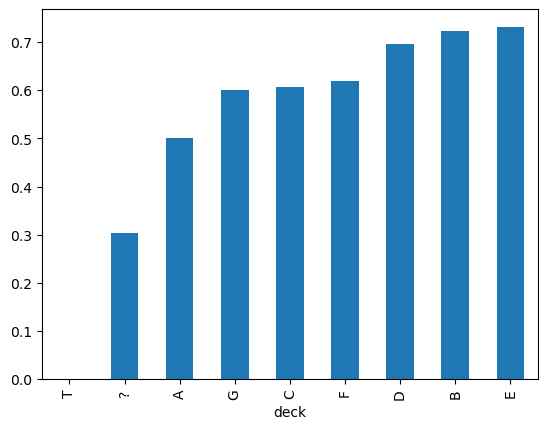

In [21]:
titanic.groupby('deck')['survived'].mean().sort_values().plot(kind='bar')

In [22]:
#STRING
titanic.cabin.str[-1:]

0       5
1       6
2       6
3       6
4       6
       ..
1304    ?
1305    ?
1306    ?
1307    ?
1308    ?
Name: cabin, Length: 1309, dtype: object

In [26]:
a = pd.Series(['1. Hawk.   ', '2. Hawk.\n', '3.Melonhea?\t' ])
a.str.strip()

0       1. Hawk.
1       2. Hawk.
2    3.Melonhea?
dtype: object

In [27]:
a.str.strip(to_strip='123.')

0       Hawk.   
1        Hawk.\n
2    Melonhea?\t
dtype: object

In [30]:
a.str.lstrip(to_strip='123.')

0       Hawk.   
1        Hawk.\n
2    Melonhea?\t
dtype: object

In [31]:
a.str.rstrip(to_strip=' \t\n')

0       1. Hawk.
1       2. Hawk.
2    3.Melonhea?
dtype: object

In [33]:
#Split
titanic['home.dest'].str.split('/', expand=True)

,0,1,2
0,"St Louis, MO",None,None
1,"Montreal, PQ","Chesterville, ON",None
2,"Montreal, PQ","Chesterville, ON",None
3,"Montreal, PQ","Chesterville, ON",None
4,"Montreal, PQ","Chesterville, ON",None
...,...,...,...
1304,?,None,None
1305,?,None,None
1306,?,None,None
1307,?,None,None


In [35]:
titanic['destination'] = titanic['home.dest'].str.split('/', expand=True)[1]

In [37]:
titanic['home.dest'].str.split('/', expand=True, n=1) #split at most once

,0,1
0,"St Louis, MO",None
1,"Montreal, PQ","Chesterville, ON"
2,"Montreal, PQ","Chesterville, ON"
3,"Montreal, PQ","Chesterville, ON"
4,"Montreal, PQ","Chesterville, ON"
...,...,...
1304,?,None
1305,?,None
1306,?,None
1307,?,None


In [39]:
ufos = pd.read_csv('../data/nuforc_reports.csv')
ufos['duration'].str.replace('seconds', 's')

0              5 s
1            3-5 s
2              NaN
3             10 s
4        2 minutes
           ...    
88120    3 minutes
88121         20 s
88122         20 s
88123    2 minutes
88124    3 minutes
Name: duration, Length: 88125, dtype: object

In [40]:
ufos['duration'].str.replace('seconds|minutes', '', regex=True)

0          5 
1        3-5 
2         NaN
3         10 
4          2 
         ... 
88120      3 
88121     20 
88122     20 
88123      2 
88124      3 
Name: duration, Length: 88125, dtype: object

In [42]:
def abbrv(regexobj):
    return regexobj.group()[0]
ufos['duration'].str.replace('seconds|minutes|hours', abbrv, regex=True)

0          5 s
1        3-5 s
2          NaN
3         10 s
4          2 m
         ...  
88120      3 m
88121     20 s
88122     20 s
88123      2 m
88124      3 m
Name: duration, Length: 88125, dtype: object

In [43]:
ufos[ufos['duration'].str.contains('hour', na=False)]

,summary,city,state,date_time,shape,duration,stats,report_link,text,posted,city_latitude,city_longitude
10,Metal orb of wires that was seen through a tel...,Brookville,IN,2019-06-18T21:00:00,sphere,1 hour,Occurred : 6/18/2019 21:00 (Entered as : 6/18...,http://www.nuforc.org/webreports/146/S146900.html,Metal orb of wires that was seen through a tel...,2019-06-20T00:00:00,39.404700,-84.973600
14,Bright Circle of Light followed me from Oskalo...,Centerville,IA,1999-08-15T02:30:00,circle,1 hour,Occurred : 8/15/1999 02:30 (Entered as : 08/1...,http://www.nuforc.org/webreports/146/S146702.html,Bright Circle of Light followed me from Oskalo...,2019-06-20T00:00:00,40.707400,-92.921300
36,"Looked like airplanes without windows, wings,...",Morehouse,MO,NaN,cylinder,hours,Occurred : 7/15/1947 21:00 (Entered as : 07/?...,http://www.nuforc.org/webreports/049/S49557.html,"Looked like airplanes without windows, wings, ...",NaN,36.849900,-89.677200
37,01/20/51 Palm Springs CA light hou...,Palm Springs,CA,NaN,cigar,one and a half hours,Occurred : 1/20/1951 04:30 (Entered as : 01/2...,http://www.nuforc.org/webreports/050/S50060.html,01/20/51 Palm Springs CA light hou...,NaN,33.800165,-116.535373
40,"5/16/1958/ 1500 hours/ just getting dark,mount...",Cincinnati,OH,NaN,diamond,24 hours,Occurred : 5/16/1958 (Entered as : 05/16/58)...,http://www.nuforc.org/webreports/049/S49850.html,"5/16/1958/ 1500 hours/ just getting dark,mount...",NaN,39.174503,-84.481363
...,...,...,...,...,...,...,...,...,...,...,...,...
88013,Unidentified flying object seen multiple night...,New port richey,FL,2019-09-27T21:00:00,unknown,1 hour,Occurred : 9/27/2019 21:00 (Entered as : 09/2...,http://www.nuforc.org/webreports/149/S149318.html,Unidentified flying object seen multiple night...,2019-10-04T00:00:00,28.242700,-82.677239
88018,On balcony enjoying a beautiful night by the b...,New York,NY,2019-09-27T22:00:00,light,1 hour,Occurred : 9/27/2019 22:00 (Entered as : 09/2...,http://www.nuforc.org/webreports/149/S149283.html,On balcony enjoying a beautiful night by the b...,2019-10-04T00:00:00,40.744307,-73.987724
88064,Unidentified object moving very slowly across ...,Pt. St. Lucie,FL,2019-09-29T17:00:00,circle,1.5 hours,Occurred : 9/29/2019 17:00 (Entered as : 09/2...,http://www.nuforc.org/webreports/149/S149338.html,Unidentified object moving very slowly across ...,2019-10-04T00:00:00,NaN,NaN
88065,White circular object above Ft Pierce,Fort Pierce,FL,2019-09-29T17:20:00,circle,1:30 hours,Occurred : 9/29/2019 17:20 (Entered as : 9/29...,http://www.nuforc.org/webreports/149/S149345.html,White circular object above Ft Pierce Very lar...,2019-10-04T00:00:00,NaN,NaN


In [44]:
ufos[ufos['duration'].str.contains('day|week|month', na=False)]

,summary,city,state,date_time,shape,duration,stats,report_link,text,posted,city_latitude,city_longitude
107,7 large yellow lights with red center estimat...,Griffin,GA,1984-03-15T20:00:00,circle,3 months,Occurred : 3/15/1984 20:00 (Entered as : marc...,http://www.nuforc.org/webreports/050/S50375.html,7 large yellow lights with red center estimat...,2006-05-15T00:00:00,33.248869,-84.249217
116,Saw one large ship during the day around noon ...,Knoxville,TN,1986-04-04T23:00:00,rectangle,week,Occurred : 4/4/1986 23:00 (Entered as : 03150...,http://www.nuforc.org/webreports/049/S49786.html,Saw one large ship during the day around noon ...,2006-05-15T00:00:00,35.961561,-83.980115
286,film makers in hollywood where talking of film...,Arizona,AZ,1997-07-07T00:00:00,triangle,all months,Occurred : 7/7/1997 (Entered as : 7 7 1997) ...,http://www.nuforc.org/webreports/049/S49553.html,film makers in hollywood where talking of film...,2006-05-15T00:00:00,NaN,NaN
290,End of the Century UFO,Cebu City (Philippines),NaN,1998-03-01T20:00:00,other,1 to 2 months,Occurred : 3/1/1998 20:00 (Entered as : 03/01...,http://www.nuforc.org/webreports/050/S50203.html,End of the Century UFO First of all I'd like t...,2006-05-15T00:00:00,NaN,NaN
1355,A white ball of light made several appearances...,Genoa,IL,2007-01-25T22:00:00,sphere,5 months,Occurred : 1/25/2007 22:00 (Entered as : 01/2...,http://www.nuforc.org/webreports/146/S146567.html,A white ball of light made several appearances...,2019-06-07T00:00:00,42.108600,-88.686000
...,...,...,...,...,...,...,...,...,...,...,...,...
84021,The Beings and Craft of Taos County. ((NUFORC...,Taos,NM,2019-09-01T10:00:00,other,2 days,Occurred : 9/1/2019 10:00 (Entered as : 09/01...,http://www.nuforc.org/webreports/148/S148913.html,The Beings and Craft of Taos County. ((NUFORC ...,2019-09-19T00:00:00,36.414600,-105.522200
84983,In 1967 I am a little kid now. I am sleeping I...,Saugas,CA,NaN,NaN,3 days,Occurred : 6/30/1967 04:00 Reported: 12/19/201...,http://www.nuforc.org/webreports/144/S144137.html,In 1967 I am a little kid now. I am sleeping ...,NaN,NaN,NaN
85717,There was a big bright colored triangle object...,Houston,BC,2019-11-25T03:30:00,triangle,Till daylight,Occurred : 11/25/2019 03:30 (Entered as : 11/...,http://www.nuforc.org/webreports/151/S151095.html,There was a big bright colored triangle object...,2019-12-01T00:00:00,54.400000,-126.650000
86210,2 flying diamonds; red and gold lights; creaki...,Dallas,TX,2019-10-11T01:44:00,diamond,2 days,Occurred : 10/11/2019 01:44 (Entered as : 10/...,http://www.nuforc.org/webreports/150/S150378.html,2 flying diamonds; red and gold lights; creaki...,2019-12-01T00:00:00,32.835168,-96.808118
